1. Importamos librerias y definimos variables.

In [21]:
#Importamos librerias y definimos datasets
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
import scipy.stats as st

taxi_trips_df = pd.read_csv('datasets/project_sql_result_01.csv')
neighborhoods_df = pd.read_csv('datasets/project_sql_result_04.csv')
weather_trips_df = pd.read_csv('datasets/project_sql_result_07.csv')

2. Identificacion de errores

In [22]:
print(taxi_trips_df.info())
print('-' * 30)
print()
print(neighborhoods_df.info())
print('-' * 30)
print()
print(weather_trips_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null  

Conclusiones:

Al revisar los tipos de datos de los datasets, se identificaron las siguientes inconsistencias:

duration_seconds: actualmente es float64, sin embargo, la duración en segundos debe ser un número entero (int64), ya que los segundos no tienen valores decimales.

average_trips: actualmente es float64, sin embargo, el promedio de viajes debe representarse como un número entero (int64), ya que no es posible realizar una fracción de un viaje.

start_ts: actualmente es object, sin embargo, al tratarse de una marca de tiempo, el tipo de dato correcto es datetime64.

Adicionalmente, se verificaron otros posibles tipos de errores:

Valores nulos: .info() confirmó que no hay valores nulos en ninguno de los datasets. 

Duplicados: Son esperables en este dataset, ya que varios viajes pueden compartir las mismas condiciones. 

Valores fuera de rango: Los errores identificados son de tipo de dato, no de valores atípicos, por lo que no fue necesario un análisis adicional con .describe(). 

Dado lo anterior, procederemos únicamente a corregir las inconsistencias en los tipos de datos.

3. Correcion de errores

In [23]:
#Convertimos al tipo correcto de Dtype
weather_trips_df['duration_seconds'] = weather_trips_df['duration_seconds'].astype('int64')
neighborhoods_df['average_trips'] = neighborhoods_df['average_trips'].astype('int64')
weather_trips_df['start_ts'] = pd.to_datetime(weather_trips_df['start_ts'])

In [24]:
#Verificamos los cambios

print(weather_trips_df.info())
print('-' * 50)
print(neighborhoods_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 25.2+ KB
None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dropoff_location_name  94 non-null     object
 1   average_trips          94 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB
None


4. 10 barrios principales en términos de finalizacion del recorrido



In [25]:
barrios_principales = neighborhoods_df.sort_values(by='average_trips', ascending=False)
print(barrios_principales.head(10))

  dropoff_location_name  average_trips
0                  Loop          10727
1           River North           9523
2         Streeterville           6664
3             West Loop           5163
4                O'Hare           2546
5             Lake View           2420
6            Grant Park           2068
7         Museum Campus           1510
8            Gold Coast           1364
9    Sheffield & DePaul           1259


5. Graficar los numeros de viajes por empresas de taxis y los 10 barrios principales por numero de finalizaciones

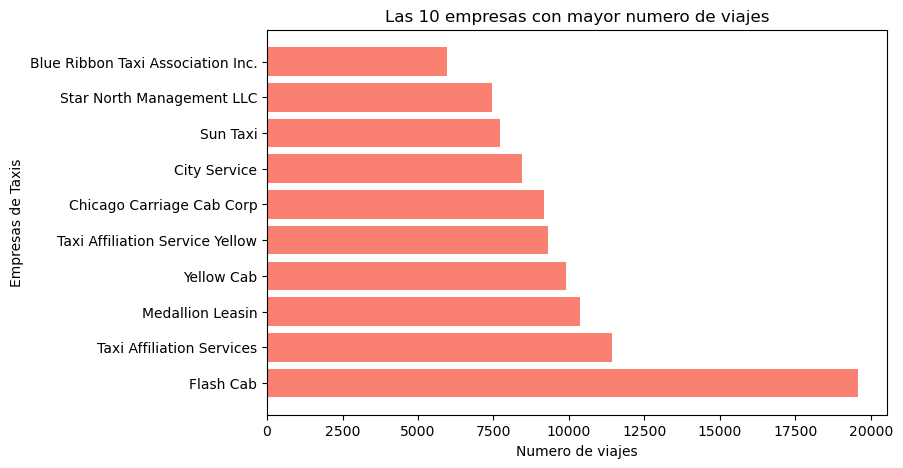

In [26]:

#5.1 Empresas de taxis por numero de viajes
top10_empresas = taxi_trips_df.sort_values(by='trips_amount', ascending=False).head(10)


plt.figure(figsize=(8, 5))
plt.barh(top10_empresas['company_name'].head(10), top10_empresas['trips_amount'].head(10), color='salmon')
plt.title('Las 10 empresas con mayor numero de viajes')
plt.xlabel('Numero de viajes')
plt.ylabel('Empresas de Taxis')
plt.show()




Conclusiones:

El análisis de la distribución del mercado muestra un liderazgo indiscutible de Flash Cab, empresa que encabeza el volumen de servicios con cerca de 19,500 viajes, superando por casi el doble a su competidor más cercano, Taxi Affiliation Services (aprox. 11,400 viajes). A partir de la tercera posición, ocupada por Medallion Leasing, se observa un comportamiento mucho más homogéneo y una competencia equilibrada entre las demás firmas del sector (cuyos rangos oscilan de manera estable entre los 6,000 y 10,000 viajes). Estos hallazgos confirman que, mientras el resto del mercado se encuentra atomizado y con diferencias marginales, Flash Cab consolida una ventaja competitiva masiva en la preferencia de los usuarios.

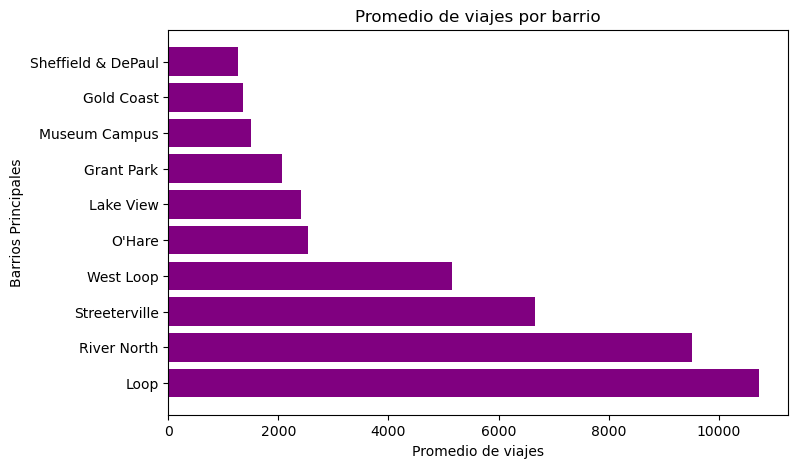

In [27]:
#5.2 Promedio de viajes por barrio

plt.figure(figsize=(8,5))
plt.barh(barrios_principales['dropoff_location_name'].head(10), barrios_principales['average_trips'].head(10), color='purple')
plt.title('Promedio de viajes por barrio')
plt.xlabel('Promedio de viajes')
plt.ylabel('Barrios Principales')
plt.show()

Conclusiones: 

El análisis identifica a Loop como el principal foco de demanda, registrando el promedio más alto con más de 10,500 viajes. Le siguen de cerca River North (aprox. 9,500 viajes) y Streeterville (aprox. 6,650 viajes), consolidando a estos tres barrios como el núcleo de mayor actividad. A partir de West Loop (5,100 viajes), se observa un descenso marcado hacia el resto de las localidades, las cuales muestran promedios significativamente menores (por debajo de los 3,000 viajes).

6. Prueba de Hipotesis

Con el objetivo de determinar el impacto de las condiciones climaticas en el sistema de transporte, se procedera a evaluar estadisticamente la siguiente hipotesis: La duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare presenta una variacion significativa durante los sabados lluviosos.

Para formalizar este analisis, se plantean las hipotesis nula y alternativa en los siguientes terminos:

Hipotesis Nula (H0): La duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es estadisticamente identica tanto en dias con clima favorable como en sabados lluviosos (las medias de ambas poblaciones son iguales).

Hipotesis Alternativa (H1): La duracion promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare difiere significativamente los sabados lluviosos en comun con los dias de clima optimo (las medias de ambos grupos son distintas).

A continuacion, se ejecutara una prueba de significacion estadistica para contrastar los datos muestrales, evaluar el valor p y determinar si existe evidencia suficiente para rechazar la hipotesis nula en favor de la alternativa.

In [28]:
#Definiremos variables para cada grupo facilitando asi su analisis posterior

grupo_bad = (weather_trips_df['start_ts'].dt.dayofweek == 5) & (weather_trips_df['weather_conditions'] == 'Bad')
weather_trips_bad = weather_trips_df[grupo_bad]

grupo_good = (weather_trips_df['start_ts'].dt.dayofweek == 5) & (weather_trips_df['weather_conditions'] == 'Good')
weather_trips_good = weather_trips_df[grupo_good]

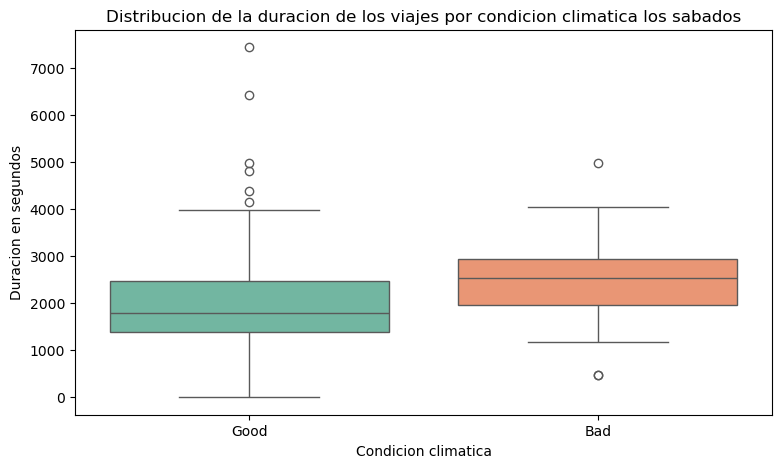

In [31]:
# Creamos un diagrama de caja para visualizar los datos
sabados_df = weather_trips_df[weather_trips_df['start_ts'].dt.dayofweek == 5]

plt.figure(figsize=(9, 5))

sns.boxplot(x='weather_conditions', y='duration_seconds', data=sabados_df, hue='weather_conditions', legend=False, palette='Set2')
plt.title('Distribucion de la duracion de los viajes por condicion climatica los sabados')
plt.xlabel('Condicion climatica')
plt.ylabel('Duracion en segundos')
plt.show()

El diagrama de caja expone una diferencia clara en el comportamiento central de ambas condiciones. Durante jornadas con clima adverso (Bad), la mediana se desplaza notablemente al alza (cercana a los 2500 segundos), lo que confirma un incremento generalizado en los tiempos de viaje provocado por las condiciones climatologicas.

Por otro lado, la presencia de valores atipicos extremos en dias con clima favorable (Good) los cuales superan los 6000 segundos no invalida la tendencia central. Estas anomalias puntuales responden a factores externos ajenos al clima, tales como congestionamiento por eventos masivos o una mayor representacion muestral de dias despejados, lo que eleva la probabilidad estadistica de registrar eventos aislados de duracion severa. En conclusion, el grafico sustenta visualmente la hipotesis de que el mal clima incrementa de manera consistente la duracion base de los traslados.

In [30]:
#Establecemos el valor alpha 
alpha = 0.05

resultados = st.ttest_ind(weather_trips_bad['duration_seconds'], weather_trips_good['duration_seconds'])

print('Valor p:', resultados.pvalue)

if resultados.pvalue < alpha:
    print("Rechazamos la hipotesis nula: existe una diferencia significativa en la duracion de los viajes.")
else:
    print("No podemos rechazar la hipotesis nula: no hay evidencia suficiente para afirmar que la duracion cambia.")

Valor p: 6.517970327099473e-12
Rechazamos la hipotesis nula: existe una diferencia significativa en la duracion de los viajes.


Conclusión de la prueba de hipótesis

Tras ejecutar la prueba t de Student para muestras independientes, se obtuvo un valor p de 6.51e-12. Al ser este resultado notablemente inferior al nivel de significancia alfa de 0.05, se procedió a rechazar la hipótesis nula en favor de la hipótesis alternativa.

Este análisis se fundamentó en los siguientes criterios estructurados:

Planteamiento de hipótesis:
La hipótesis nula determinaba que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare se mantenía idéntica sin importar las condiciones climáticas. Por el contrario, la hipótesis alternativa sostenía que la duración promedio de los traslados presentaba una diferencia significativa durante los sábados lluviosos.

Criterio de prueba utilizado:
Se empleó el contraste directo entre el valor p calculado y el nivel de significancia alfa establecido en 0.05. Este criterio se seleccionó debido a que es el estándar probabilístico en la ciencia de datos; un valor p extremadamente cercano a cero demuestra que la diferencia observada en las duraciones de los viajes es estadísticamente sólida y no puede atribuirse al azar o a la casualidad muestral.